<a href="https://colab.research.google.com/github/tuchanski/spambase-classification/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Report - Data Science

## Bachelor's Degree in Computer Science / PUCPR (2026-2)

**Prof. Rayson Laroca**

`Guilherme Tuchanski Rocha` - `guilherme.tuchanski@gmail.com | guilherme.tuchanski@pucpr.edu.br`

### Project Overview: Email Spam Classification

This project addresses the task of **email spam classification** using the **Spambase** dataset from the UCI Machine Learning Repository. The objective is to analyze characteristics extracted from email messages and investigate how these features differ between spam and legitimate emails.

The dataset contains numerical features related to the frequency of specific words and characters, as well as information about sequences of consecutive capital letters. These characteristics can be explored to identify patterns associated with spam messages.

During the project, the dataset will be analyzed through descriptive statistics, univariate and multivariate analyses, and data visualizations. In later stages, machine learning models will be trained and evaluated to classify emails as spam or non-spam.

#### Dataset Characteristics

* **Instances:** 4,601 records in the original dataset.
* **Features:** 57 numerical features describing word frequencies, character frequencies, and capitalization patterns.
* **Target:** The `Class` variable, where `1` represents spam and `0` represents non-spam.
* **Task:** Binary classification.
* **Source:** UCI Machine Learning Repository.

# Import the libs you need

In [1]:
!pip install ucimlrepo -q

In [2]:
# Import all packages you need here
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

# Add others as needed (seaborn, sklearn, etc.)

# Load your data

Below, load the data using pandas and perform all necessary data cleaning to ensure that the data types are correct for further analysis.

In [3]:
# Load the original data and keep a copy for comparison after cleaning.
spambase = fetch_ucirepo(id=94)

X = spambase.data.features
y = spambase.data.targets

df_raw = pd.concat([X, y], axis=1).copy()
df = df_raw.copy()
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum().sum())

df.head()

(4601, 58)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report      

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [5]:
# Start from the original data so this section can be run again safely.
df = df_raw.copy()
print(f"Number of records before cleaning: {len(df)}")

Number of records before cleaning: 4601


In [6]:
# 1. Require numeric values; stop if an unexpected text value is found.
df = df.apply(pd.to_numeric, errors="raise")

# Missing or infinite values need investigation before analysis can continue.
missing_values = df.isna().sum().sum()
infinite_values = np.isinf(df.to_numpy()).sum()
print(f"Missing values: {missing_values}")
print(f"Infinite values: {infinite_values}")
assert missing_values == 0, "Investigate missing values before continuing."
assert infinite_values == 0, "Investigate infinite values before continuing."

Missing values: 0
Infinite values: 0


In [7]:
# 2. Validate labels BEFORE converting to integers (0.5 must not become 0).
assert df["Class"].isin([0, 1]).all(), "Class must contain only 0 or 1."
df["Class"] = df["Class"].astype(int)
print(f"Class values: {sorted(df['Class'].unique())}")

Class values: [np.int64(0), np.int64(1)]


In [8]:
# 3. Frequencies are percentages, so valid values range from 0 to 100.
frequency_cols = df.filter(regex=r"^(word_freq_|char_freq_)").columns
assert df[frequency_cols].ge(0).all().all(), "Negative frequency found."
assert df[frequency_cols].le(100).all().all(), "Frequency above 100 found."

# Zero frequencies mean absence; keep them and do not remove outliers blindly.
average = df["capital_run_length_average"]
longest = df["capital_run_length_longest"]
total = df["capital_run_length_total"]
assert average.ge(0).all(), "Negative capital run length found."
assert (average <= longest).all(), "Average run length exceeds the longest run."
assert (longest <= total).all(), "Longest run exceeds total capital letters."
assert ((longest % 1 == 0) & (total % 1 == 0)).all(), "Capital counts must be integers."

In [9]:
# 4. Keep one copy of each identical row to reduce repeated observations.
# This is an analysis choice: matching features do not prove emails are identical.
duplicates = df.duplicated().sum()
df = df.drop_duplicates().copy()
print(f"Duplicate rows removed: {duplicates}")

# Check for identical features with different labels; keep them for review.
feature_cols = df.columns.drop("Class").tolist()
label_counts = df.groupby(feature_cols, dropna=False)["Class"].nunique()
print(f"Feature groups with conflicting labels: {(label_counts > 1).sum()}")
# Later, keep identical feature groups in the same train/test partition.

Duplicate rows removed: 391
Feature groups with conflicting labels: 3


In [10]:
# 5. Compare class percentages to see the effect of removing duplicates.
class_balance = pd.DataFrame({
    "Before (%)": df_raw["Class"].value_counts(normalize=True) * 100,
    "After (%)": df["Class"].value_counts(normalize=True) * 100,
}).sort_index()
display(class_balance.round(2))

,Before (%),After (%)
Class,,
0,60.6,60.12
1,39.4,39.88


In [11]:
# 6. Rebuild X and y so later analysis uses the cleaned data.
X = df.drop(columns="Class").copy()
y = df["Class"].copy()

# Fit scaling or imputation only on training data during the modeling stage.
print("Data types:")
print(df.dtypes.value_counts())

Data types:
float64    55
int64       3
Name: count, dtype: int64


In [12]:
# Final summary; retain original row indices to trace records back to df_raw.
print(f"Number of records after cleaning: {len(df)}")
print(f"Number of features: {X.shape[1]}")
display(df.head())

Number of records after cleaning: 4210
Number of features: 57


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


# Statistical Description

In this section, you should report the key characteristics of the dataset, including but not limited to:
* the number of instances;
* the number of features;
* the type of target variable or task;
* the number of classes, for classification problems;
* the class distribution, for classification problems;
* the distribution and range of the target variable, for regression problems.

In [16]:
features = df.drop(columns="Class")
target = df["Class"]

summary = pd.Series({
    "Number of instances": len(df),
    "Number of features": features.shape[1],
    "Feature type": "Numeric (word/character frequencies and capital run lengths)",
    "Task": "Binary classification",
    "Target variable": "Class (0 = non-spam, 1 = spam)",
    "Number of classes": target.nunique(),
}, name="Value")
display(summary.to_frame())

,Value
Number of instances,4210
Number of features,57
Feature type,Numeric (word/character frequencies and capita...
Task,Binary classification
Target variable,"Class (0 = non-spam, 1 = spam)"
Number of classes,2


In [17]:
# Show both counts and percentages to make the class balance easy to compare.
class_distribution = target.value_counts().sort_index().rename("Count").to_frame()
class_distribution["Percentage (%)"] = (class_distribution["Count"] / len(df) * 100).round(2)
class_distribution.index = class_distribution.index.map({0: "Non-spam (0)", 1: "Spam (1)"})
class_distribution.index.name = "Class"
display(class_distribution)

,Count,Percentage (%)
Class,,
Non-spam (0),2531,60.12
Spam (1),1679,39.88


In [18]:
# Use the majority class as a simple reference for later model evaluation.
majority_percentage = class_distribution["Count"].max() / len(df) * 100
print(f"Always predicting the majority class would give {majority_percentage:.2f}% accuracy.")

Always predicting the majority class would give 60.12% accuracy.


The target is categorical even though it is encoded as integers: **0 means non-spam** and **1 means spam**. The 57 predictors describe word frequencies (48 features), character frequencies (6 features), and capital letter sequences (3 features).

After cleaning, the dataset contains **4,210 emails**: **2,531 non-spam (60.12%)** and **1,679 spam (39.88%)**. Non-spam is the majority class, but both classes are well represented. Accuracy should be compared with the majority-class baseline and complemented by precision, recall, and F1-score during model evaluation. These percentages describe this dataset and should not be assumed to represent all email traffic.

# Univariate data analysis

In this section, you should perform univariate data analysis on at least **20 variables**.

In the end, you should describe the main variables that are of your interest, and these should be accounted for in the next sections of the report.
The definition of each variable chosen should be clarified, so arbitrary selections are **not** accepted at this point.

For each variable plotted, make sure you determine the following:
1. The distribution of the data (Gaussian, binomial, exponential, etc.);
2. Skewness;
3. Kurtosis;
4. Mean, standard deviation, and what they stand for in the context of the dataset.

Ensure that each variable is **plotted correctly** based on its type. For instance, make sure scatterplots are not used for categorical data and so forth.

## Approach and variable selection

We analyze **20 numerical predictors and the target**, using the cleaned `df`. Each variable is examined separately; relationships with spam will be investigated in the multivariate section. The selection covers message content, punctuation, and capitalization, based on their meaning rather than a ranking against the target.

For `word_freq_WORD`, the value is the percentage of words matching that token. For `char_freq_CHAR`, it is the percentage of characters matching that symbol. A zero indicates absence. Capital run lengths describe consecutive uppercase letters. These definitions follow the [UCI Spambase documentation](https://archive.ics.uci.edu/dataset/94/spambase).

| Variable | Definition | Reason for inclusion |
|---|---|---|
| `word_freq_free` | Percentage of words equal to “free” | Explore language about free offers. |
| `word_freq_money` | Percentage of words equal to “money” | Explore financial language. |
| `word_freq_credit` | Percentage of words equal to “credit” | Explore credit-related content. |
| `word_freq_order` | Percentage of words equal to “order” | Explore purchasing language. |
| `word_freq_business` | Percentage of words equal to “business” | Explore commercial or professional content. |
| `word_freq_remove` | Percentage of words equal to “remove” | Explore a possible unsubscribe-related token. |
| `word_freq_you` | Percentage of words equal to “you” | Measure direct address to the reader. |
| `word_freq_your` | Percentage of words equal to “your” | Measure another form of reader-directed language. |
| `word_freq_hp` | Percentage of words equal to “hp” | Explore vocabulary tied to the dataset's organizational context. |
| `word_freq_george` | Percentage of words equal to “george” | Explore a personal name specific to this collection. |
| `word_freq_meeting` | Percentage of words equal to “meeting” | Explore workplace or scheduling content. |
| `word_freq_re` | Percentage of words equal to “re” | Explore a token that may occur in replies; this is not a subject-line indicator. |
| `char_freq_!` | Percentage of exclamation marks | Measure emphatic punctuation. |
| `char_freq_$` | Percentage of dollar signs | Explore monetary notation. |
| `char_freq_#` | Percentage of hash signs | Explore numbering or formatting. |
| `char_freq_(` | Percentage of opening parentheses | Explore punctuation used in explanations or formatting. |
| `char_freq_;` | Percentage of semicolons | Explore another writing or formatting pattern. |
| `capital_run_length_average` | Average uppercase run length in an email | Measure typical uppercase sequence length within a message. |
| `capital_run_length_longest` | Longest uppercase run in an email | Measure the most sustained uppercase sequence. |
| `capital_run_length_total` | Total uppercase letters in an email | Measure overall uppercase volume; this also depends on message length. |
| `Class` | 0 = non-spam, 1 = spam | Describe the target distribution for later comparisons. |

These reasons are exploratory hypotheses, not evidence that a variable identifies spam.

In [1]:
import matplotlib.pyplot as plt

# Keep named groups so the selection is explicit and reusable in later sections.
univariate_groups = {
    "Commercial and subscription vocabulary": [
        "word_freq_free", "word_freq_money", "word_freq_credit",
        "word_freq_order", "word_freq_business", "word_freq_remove",
    ],
    "Reader and contextual vocabulary": [
        "word_freq_you", "word_freq_your", "word_freq_hp",
        "word_freq_george", "word_freq_meeting", "word_freq_re",
    ],
    "Punctuation": [
        "char_freq_!", "char_freq_$", "char_freq_#", "char_freq_(", "char_freq_;",
    ],
    "Capitalization": [
        "capital_run_length_average", "capital_run_length_longest",
        "capital_run_length_total",
    ],
}
selected_features = [column for columns in univariate_groups.values() for column in columns]
univariate_variables = selected_features + ["Class"]

# Work on a separate selection; plotting must not modify the cleaned data.
univariate_data = df[selected_features].copy()
print(f"Analyzing {len(selected_features)} predictors and Class across {len(df):,} emails.")

Analyzing 20 predictors and Class across 4,210 emails.


## How to read the statistics and plots

The tables report statistics on the **original values**. The mean is the average across emails; the sample standard deviation measures variation around that mean. For frequencies, means are percentages and standard deviations are **percentage points**. Each email receives equal weight, so a mean word frequency is not the percentage obtained by pooling every word in the dataset. Capitalization means and standard deviations are measured in letters; the mean of `capital_run_length_average` averages the per-email averages.

The median and quartiles help describe typical emails when extreme values pull the mean upward. Positive skewness indicates a longer right tail, negative skewness a longer left tail. We use **excess kurtosis**, where a Gaussian distribution has value 0; large positive values indicate strong tail/extreme-value influence relative to that reference. Neither statistic alone identifies a probability distribution.

Each histogram shows one numeric variable using 30 bins of **`log1p(value)`**, meaning the natural logarithm of one plus the value. This compresses long right tails while preserving zeros and all observations. The horizontal axis is transformed; tables and annotated statistics remain in original units. This is only a visualization choice, not a transformation of `df` or a modeling decision. Dashed lines mark the transformed locations of the original mean and median.

We describe empirical distribution shapes without fitting Gaussian or exponential models. Frequency variables can combine an exact-zero mass with positive values. The two uppercase counts are discrete; average run length and frequencies are treated as continuous. The binary target uses a bar chart.

In [2]:
# Add robust summaries and zero percentages because averages alone can hide sparsity.
univariate_stats = univariate_data.describe().T.rename(columns={
    "count": "Count", "mean": "Mean", "std": "Std. dev.",
    "min": "Min", "25%": "Q1", "50%": "Median", "75%": "Q3", "max": "Max",
})
univariate_stats["Zero (%)"] = univariate_data.eq(0).mean() * 100
univariate_stats["Skewness"] = univariate_data.skew()
# pandas reports Fisher's excess kurtosis: the Gaussian reference is zero.
univariate_stats["Excess kurtosis"] = univariate_data.kurt()

def describe_univariate_group(group_name):
    columns = univariate_groups[group_name]
    # Two narrow tables are easier to read than one table with every statistic.
    display(univariate_stats.loc[columns, [
        "Mean", "Std. dev.", "Min", "Q1", "Median", "Q3", "Max",
    ]].round(3))
    display(univariate_stats.loc[columns, [
        "Zero (%)", "Skewness", "Excess kurtosis",
    ]].round(3))

    rows = (len(columns) + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(15, 3.8 * rows), squeeze=False)
    for ax, column in zip(axes.flat, columns):
        values = univariate_data[column]
        stats = univariate_stats.loc[column]
        ax.hist(np.log1p(values), bins=30, color="#4477AA", edgecolor="white")
        ax.axvline(np.log1p(stats["Mean"]), color="#BB5566", linestyle="--", label="Mean")
        ax.axvline(np.log1p(stats["Median"]), color="#228833", linestyle=":", label="Median")
        ax.set_title(column, fontsize=10)
        unit = "frequency (%)" if "freq_" in column else "length in letters"
        ax.set_xlabel(f"log1p({unit})")
        ax.set_ylabel("Number of emails")
        ax.text(0.97, 0.75, f"Zeros: {stats['Zero (%)']:.1f}%",
                transform=ax.transAxes, ha="right", fontsize=9)
        ax.legend(fontsize=8, loc="upper right")
    for ax in axes.flat[len(columns):]:
        ax.set_visible(False)
    fig.suptitle(group_name, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## Commercial and subscription vocabulary

,Mean,Std. dev.,Min,Q1,Median,Q3,Max
word_freq_free,0.254,0.798,0.0,0.0,0.0,0.128,20.00
word_freq_money,0.091,0.432,0.0,0.0,0.0,0.000,12.50
word_freq_credit,0.085,0.506,0.0,0.0,0.0,0.000,18.18
word_freq_order,0.092,0.282,0.0,0.0,0.0,0.000,5.26
word_freq_business,0.149,0.458,0.0,0.0,0.0,0.000,7.14
word_freq_remove,0.117,0.397,0.0,0.0,0.0,0.000,7.27


,Zero (%),Skewness,Excess kurtosis
word_freq_free,72.542,9.388,157.692
word_freq_money,84.347,15.557,340.176
word_freq_credit,90.760,15.430,424.686
word_freq_order,82.850,5.284,48.011
word_freq_business,78.480,5.568,43.514
word_freq_remove,81.900,6.809,76.382


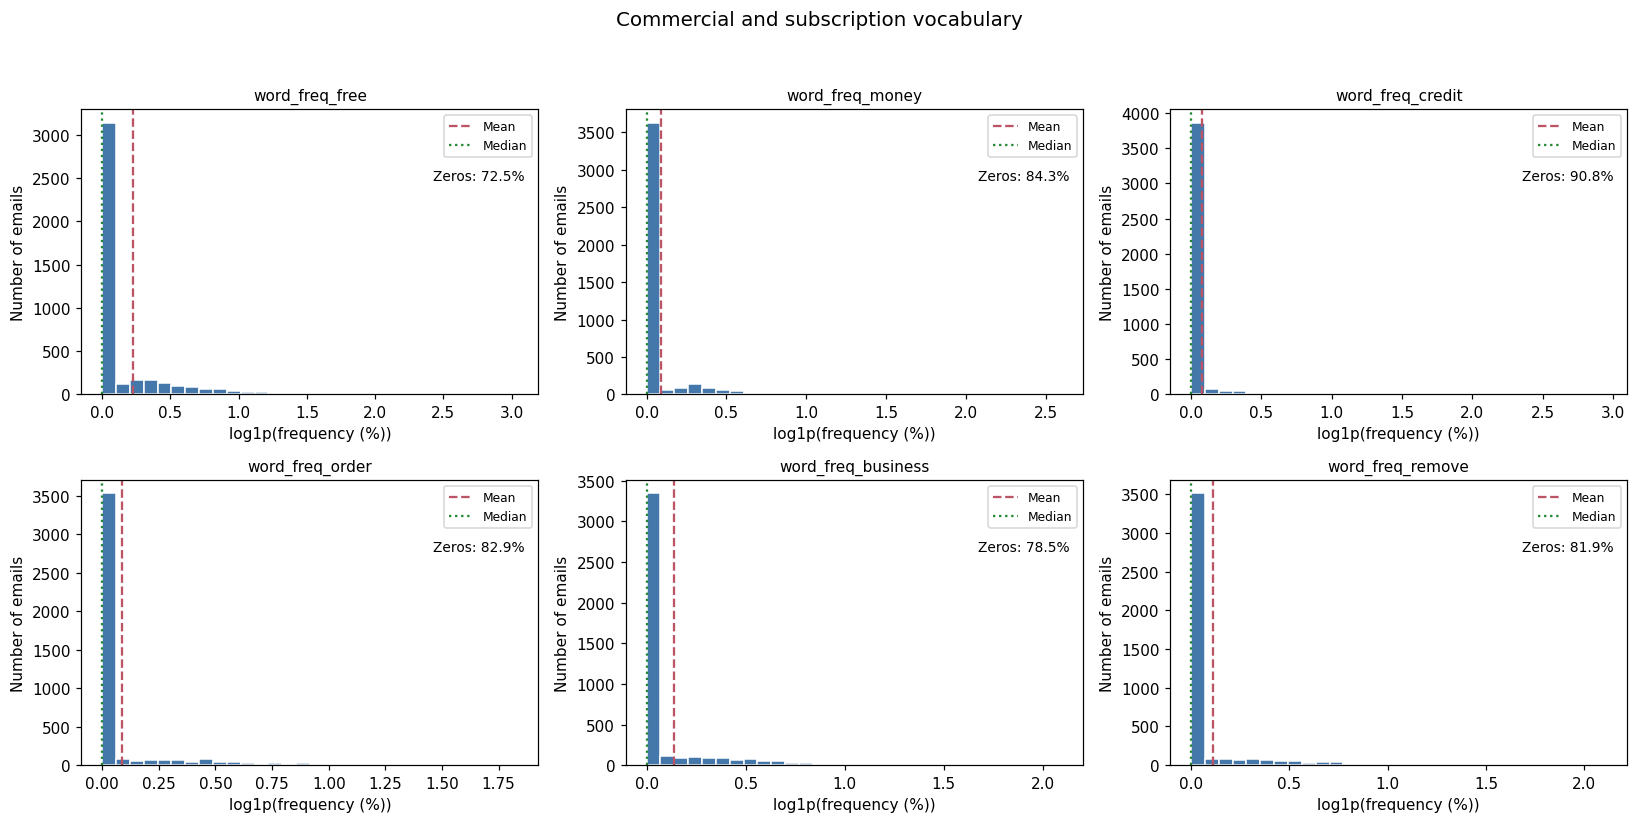

In [3]:
describe_univariate_group("Commercial and subscription vocabulary")

All six variables have **a large mass at zero and a long right tail**, rather than an approximately Gaussian shape. Their medians are zero, and positive skewness and high excess kurtosis show that uncommon large values strongly affect the averages. A simple continuous exponential model would also miss the exact-zero mass.

`free` has the highest mean in this group (about **0.254%**, standard deviation **0.798 percentage points**), but is absent from about **72.5%** of emails. `credit` is absent from about **90.8%**, and its excess kurtosis is especially large (about **424.7**). `money`, `order`, `business`, and `remove` show the same broad pattern of absence in most messages and occasional larger frequencies. These variables are useful candidates for later comparisons of both presence and frequency by class; their univariate distributions do not establish a spam association.

## Reader and contextual vocabulary

,Mean,Std. dev.,Min,Q1,Median,Q3,Max
word_freq_you,1.718,1.769,0.0,0.0,1.36,2.720,18.75
word_freq_your,0.810,1.149,0.0,0.0,0.29,1.280,11.11
word_freq_hp,0.574,1.677,0.0,0.0,0.00,0.098,20.83
word_freq_george,0.370,1.775,0.0,0.0,0.00,0.000,33.33
word_freq_meeting,0.142,0.794,0.0,0.0,0.00,0.000,14.28
word_freq_re,0.320,1.046,0.0,0.0,0.00,0.170,21.42


,Zero (%),Skewness,Excess kurtosis
word_freq_you,27.221,1.524,4.998
word_freq_your,45.724,2.246,8.094
word_freq_hp,74.727,5.639,43.182
word_freq_george,84.157,9.482,111.100
word_freq_meeting,92.043,9.185,108.995
word_freq_re,70.356,8.918,122.068


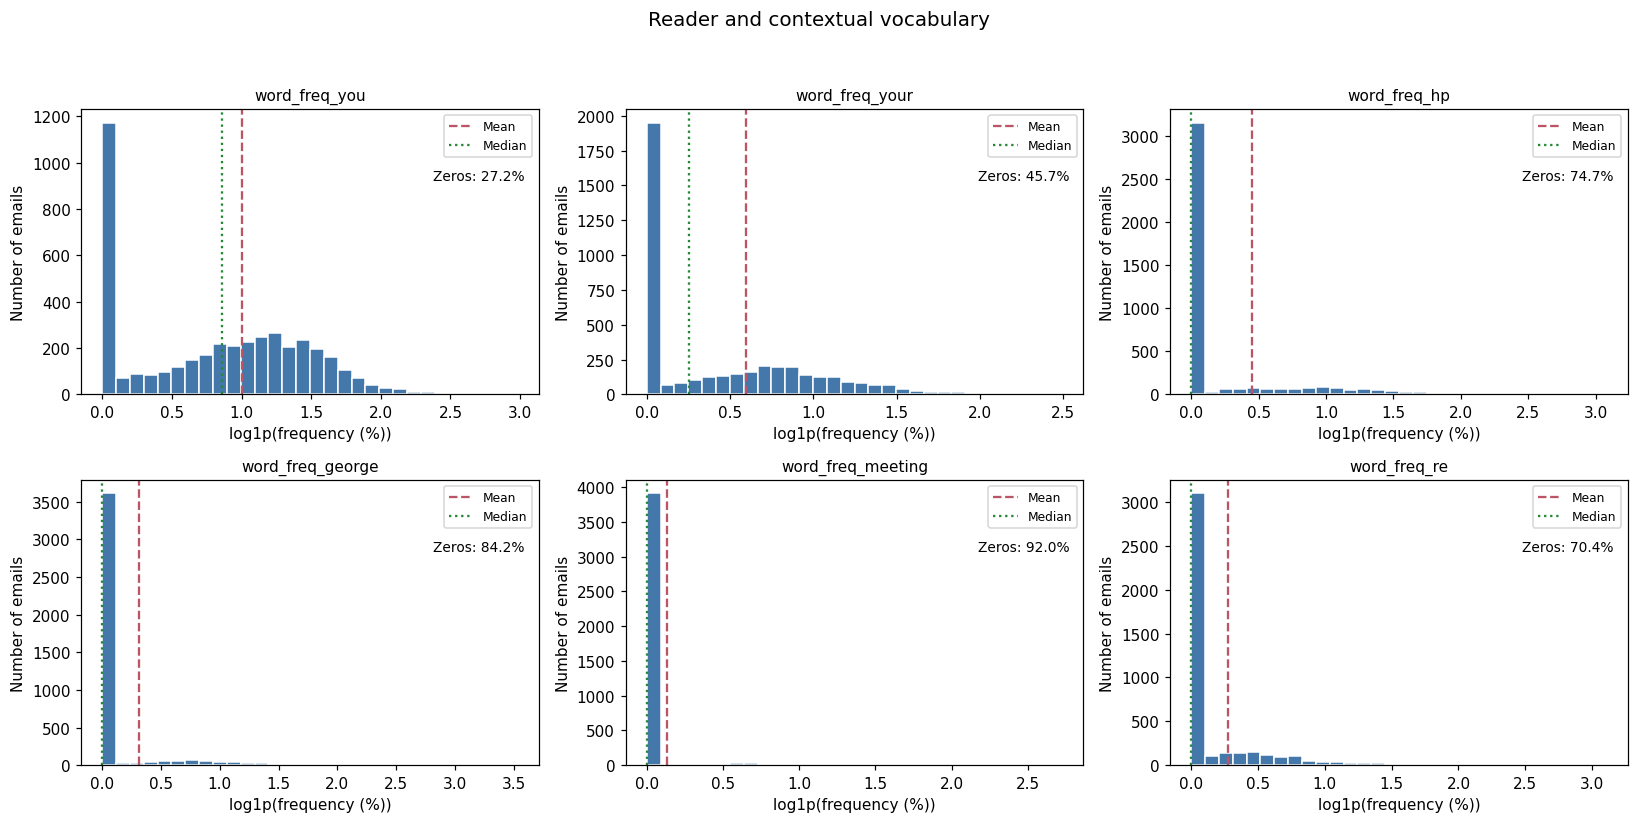

In [4]:
describe_univariate_group("Reader and contextual vocabulary")

All six distributions are **right-skewed with positive excess kurtosis**. `you` and `your` are less concentrated at zero than the other words: their zero percentages are about **27.2%** and **45.7%**, and their medians are positive. `you` has a mean of about **1.718%** and a standard deviation of **1.769 percentage points**, indicating substantial variation in direct-address language across emails.

`hp`, `george`, `meeting`, and `re` each have a zero median and a sparse positive tail. For example, `meeting` is absent from about **92.0%** of emails. These four variables are not well summarized by a symmetric Gaussian shape. Their context makes them worth comparing with the target, but vocabulary tied to this particular collection may not generalize to other email sources.

## Punctuation

,Mean,Std. dev.,Min,Q1,Median,Q3,Max
char_freq_!,0.281,0.843,0.0,0.0,0.016,0.331,32.478
char_freq_$,0.076,0.240,0.0,0.0,0.000,0.053,6.003
char_freq_#,0.046,0.436,0.0,0.0,0.000,0.000,19.829
char_freq_(,0.144,0.274,0.0,0.0,0.073,0.194,9.752
char_freq_;,0.040,0.253,0.0,0.0,0.000,0.000,4.385


,Zero (%),Skewness,Excess kurtosis
char_freq_!,49.121,18.337,579.438
char_freq_$,69.169,10.609,188.463
char_freq_#,83.325,31.500,1238.321
char_freq_(,38.670,14.003,404.370
char_freq_;,82.185,13.356,200.450


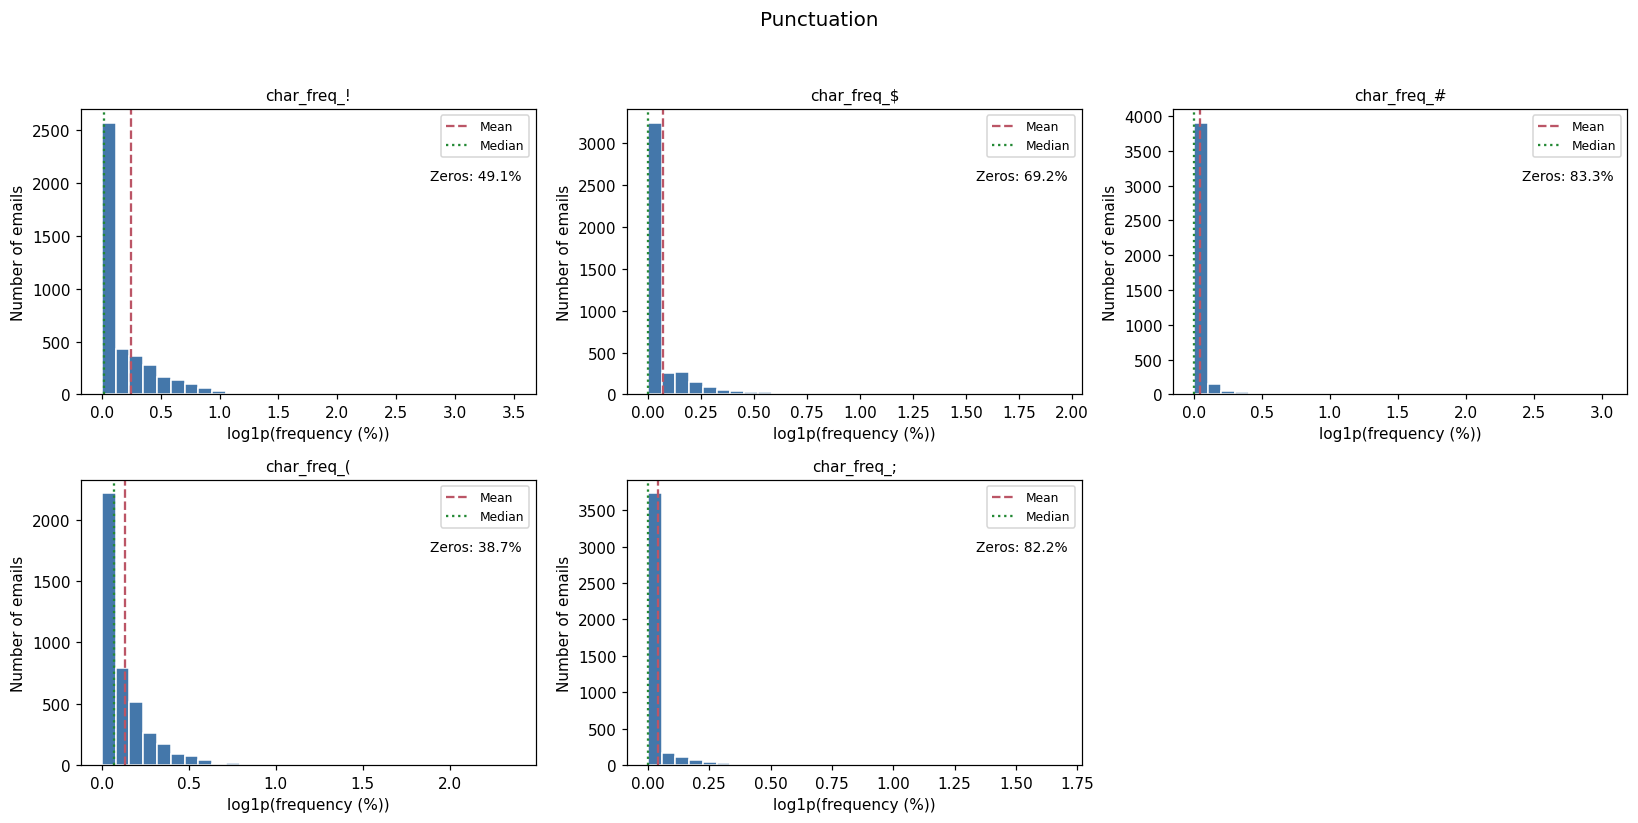

In [5]:
describe_univariate_group("Punctuation")

Each punctuation variable has **an exact-zero mass and a long right tail**, with positive skewness and high excess kurtosis. Exclamation marks and opening parentheses have positive medians; dollar signs, hash signs, and semicolons have zero medians.

`char_freq_!` averages about **0.281%** with a standard deviation of **0.843 percentage points**. Its small median (**0.016%**) shows how much larger the mean is than a typical central value. `char_freq_#` has particularly extreme skewness (about **31.5**) and excess kurtosis (about **1,238.3**), despite a mean of only **0.046%**. Rare high frequencies deserve attention, but the univariate results do not justify deleting them or assuming they are errors.

## Capitalization

,Mean,Std. dev.,Min,Q1,Median,Q3,Max
capital_run_length_average,5.384,33.147,1.0,1.628,2.297,3.707,1102.5
capital_run_length_longest,52.140,199.582,1.0,7.000,15.000,44.000,9989.0
capital_run_length_total,291.182,618.655,1.0,40.000,101.500,273.750,15841.0


,Zero (%),Skewness,Excess kurtosis
capital_run_length_average,0.0,22.761,614.400
capital_run_length_longest,0.0,31.205,1471.216
capital_run_length_total,0.0,8.802,146.108


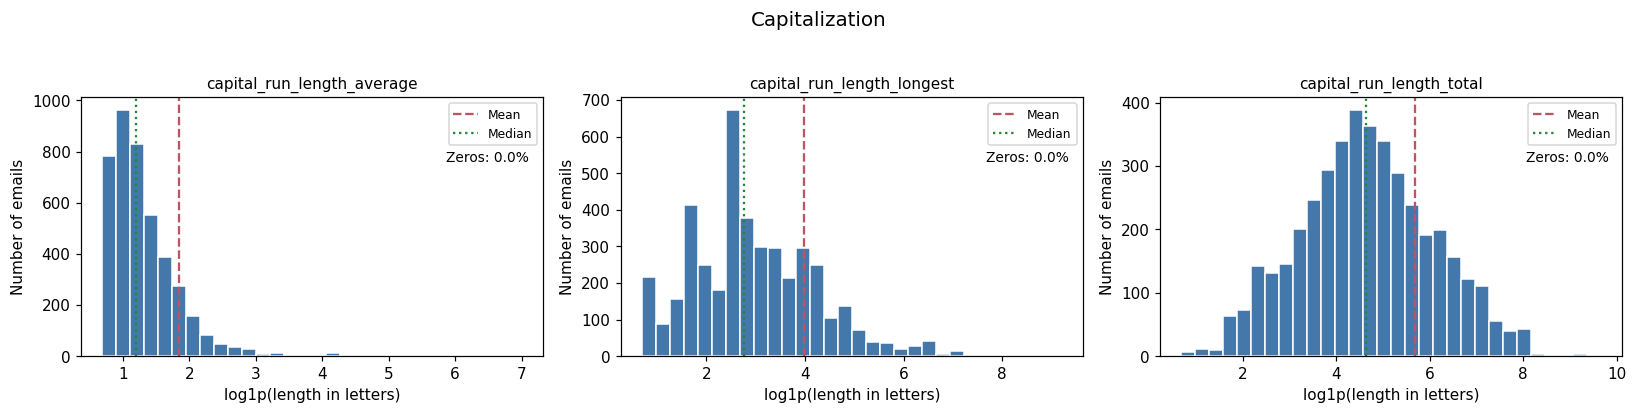

In [6]:
describe_univariate_group("Capitalization")

All three capitalization variables are **strongly right-skewed with long upper tails** and no zeros in the cleaned dataset. Their positive skewness and very high excess kurtosis do not support an approximately Gaussian description on the original scale. The longest run and total uppercase volume are discrete counts; the average run length is continuous. A named distribution is not established here.

The per-email average run length has a mean of about **5.384 letters** and a standard deviation of **33.147 letters**, compared with a median of **2.297**. The longest run averages **52.140 letters** with a standard deviation of **199.582**, while its median is only **15** and its maximum is **9,989**. Total uppercase volume averages **291.182 letters** with a standard deviation of **618.655**, compared with a median of **101.5**. These gaps show why the median and quartiles are useful alongside the mean. Total uppercase volume can also reflect email length, which these three variables alone cannot separate from capitalization style.

## Target distribution

`Class` is categorical, so counts are shown with a bar chart. For a single email, its 0/1 encoding can be described by a **Bernoulli distribution**, with the spam probability estimated by the observed proportion. The mean is therefore the spam fraction. The standard deviation measures the spread of the binary indicator; skewness and excess kurtosis describe its encoded distribution, not an ordered measure of email quality.

,Class
Mean (spam fraction),0.3988
Std. dev. (binary indicator),0.4897
Skewness,0.4134
Excess kurtosis,-1.8299


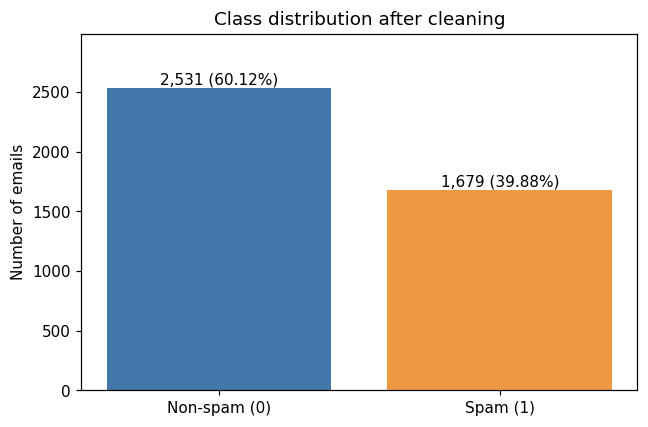

In [7]:
# Fix the category order so both labels remain explicit.
class_counts = df["Class"].value_counts().reindex([0, 1], fill_value=0)
class_percentages = class_counts / len(df) * 100
target_stats = pd.Series({
    "Mean (spam fraction)": df["Class"].mean(),
    "Std. dev. (binary indicator)": df["Class"].std(),
    "Skewness": df["Class"].skew(),
    "Excess kurtosis": df["Class"].kurt(),
}, name="Class")
display(target_stats.round(4).to_frame())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Non-spam (0)", "Spam (1)"], class_counts, color=["#4477AA", "#EE9944"])
for bar, count, percentage in zip(bars, class_counts, class_percentages):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 35,
            f"{count:,} ({percentage:.2f}%)", ha="center")
ax.set_ylim(0, class_counts.max() * 1.18)
ax.set_ylabel("Number of emails")
ax.set_title("Class distribution after cleaning")
fig.tight_layout()
plt.show()

The empirical Bernoulli parameter is approximately **0.399**: about **39.88%** of the cleaned emails are spam and **60.12%** are non-spam. The binary indicator's sample standard deviation is about **0.490**. Its slight positive skewness reflects the less frequent value 1; negative excess kurtosis is consistent with a two-point distribution and is not a data-quality issue.

## Main findings and variables for the next section

The selected numeric predictors all have right-skewed distributions and positive excess kurtosis. Most selected word frequencies have zero medians, while a small number of large observations raise the means. We retain zeros and extreme values: absence is meaningful, and the earlier validation did not identify these values as invalid. No additional cleaning is performed here.

For multivariate analysis, the main candidates are **`word_freq_free`, `word_freq_money`, `word_freq_remove`, `word_freq_you`, `word_freq_your`, `word_freq_hp`, `word_freq_george`, `char_freq_!`, `char_freq_$`, and all three capitalization variables**, together with **`Class`**. They cover commercial content, reader-directed language, collection-specific vocabulary, punctuation, and uppercase usage. We can investigate how their distributions differ by class and whether related measures vary together. `char_freq_#` is also worth revisiting because of its unusually extreme tail.

The list `univariate_variables` contains every variable covered here and can be reused to keep later plots within the analyzed set. This selection is for exploration, not a final model feature set. Univariate analysis alone cannot demonstrate predictive value or relationships between variables.

# Multivariate data analysis

In this section, you should plot at least **5 multivariate visualizations**. The key here is to investigate underlying correlations and behaviors within the dataset.
Naturally, as visualizations are being created, we should end up with obvious results, yet, you should find at least **ONE** non-obvious behavior in the data.

Please follow these steps for creating your visualizations:
1. State an hypothesis. Explain why you have selected these specific variables and what you expect to discover through their relationship;
2. Determine what kind of visualization is the most suitable;
3. Report the findings and discuss whether they corroborate or not the aforementioned hypothesis.


**Hints**

In this section, make sure you go beyond naive explorations. For example, consider applying techniques such as PCA, t-SNE, or even others that we haven't covered in the lectures. The goal is to cultivate a critical mindset toward data analysis and our work.

**Important**

It is strictly prohibited to create multivariate visualizations using variables that were not included in the previous section (univariate data analysis).

In [ ]:
# again, feel free to place as many cells to plot the visualizations,
# as well as describe to the main findings

# Final Plots (Effective Data Visualization)

In this section, you need to **enhance 3 multivariate visualizations** that were presented in the previous section of the report.
The goal is to enhance these visualizations so that they can be effectively presented to an audience unfamiliar with the dataset or with data analysis.
**Therefore, make sure that their size, colors, textures, and other visual elements are appropriate and convey the intended information to the audience.**

For your final plots, make sure you follow these steps:
1. Present the plot;
2. Provide a description of the visualization, highlighting the key findings that can be drawn from it.


**Hint**: take a look at the checklist based on Evergreen’s work to ensure your visualizations meet the best practices for clarity and impact.

In [ ]:
# your code goes here

# Digest

In this section, you should briefly summarize the main findings of your project. Additionally, provide a critical reflection on your work and the effort invested throughout the module. Highlight the aspects you believe were handled successfully, as well as those that, in hindsight, you would approach differently.

While this digest must contain at least 2,500 characters, it is intended solely for self-reflection purposes and will not be considered in the formal evaluation of your work.

```
Add your text here.
```

# Checkpoint Submission *(**Ignore this component in the final submission**)*

1. Save this report as a Jupyter Notebook (`.ipynb`), ensuring that all code cells are executed and their outputs are visible in the exported notebook;
2. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document. If the generated PDF has formatting issues, include it in the submission anyway;
4. Copy the dataset (if smaller than 10 MB);
5. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive named `EquipeXX.zip`, replacing XX with your team number;
6. Upload the ZIP file to Canvas.

# Machine Learning (**post-checkpoint!**)

In this section, you must create at least **3 machine learning models** for the task at hand. Depending on the problem's nature, you must select from classification, regression, or clustering models.
It is also important that you:
* Select **an appropriate validation protocol**, providing a rationale for why it is appropriate for this specific task;
* Choose **a suitable set of evaluation metrics**, providing an explanation for each and describing how it contributes to evaluating the model's performance in the context of this specific task.

In [ ]:
# use as many cells as needed

# Final Steps (Submission)


1. Run all cells in the notebook and make sure every cell is executed successfully, with all outputs visible;
2. Save this report as a Jupyter Notebook (`.ipynb`);
3. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document. If the generated PDF has formatting issues, include it in the submission anyway;
4. Copy the dataset (if smaller than 10 MB);
5. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive (`EquipeXX.zip`);
6. Upload the ZIP file to Canvas.